## 1. Get image lists

In [26]:
import os
import glob
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt


In [3]:
folder_path = "/mnt/c/Users/Admin/Downloads/archive/ECOMMERCE_PRODUCT_IMAGES"
images_path = []

for sub_folder in os.listdir(folder_path): 
  path = os.path.join(folder_path, sub_folder)
  if sub_folder == "train" or sub_folder == "val": 
    image_list = glob.glob(path + "/**/*.jpeg", recursive=True )
    images_path.extend(image_list)

In [27]:
print("Num of images: ", len(images_path))

Num of images:  17624


In [7]:
def check_image_formats(file_list):
    exts = [os.path.splitext(f)[-1].lower() for f in file_list]
    return Counter(exts)

formats = check_image_formats(images_path)

print("Các loại định dạng ảnh trong list:")
for ext, count in formats.items():
    print(f"{ext}: {count}")

Các loại định dạng ảnh trong list:
.jpeg: 17624


## 2. Static size images



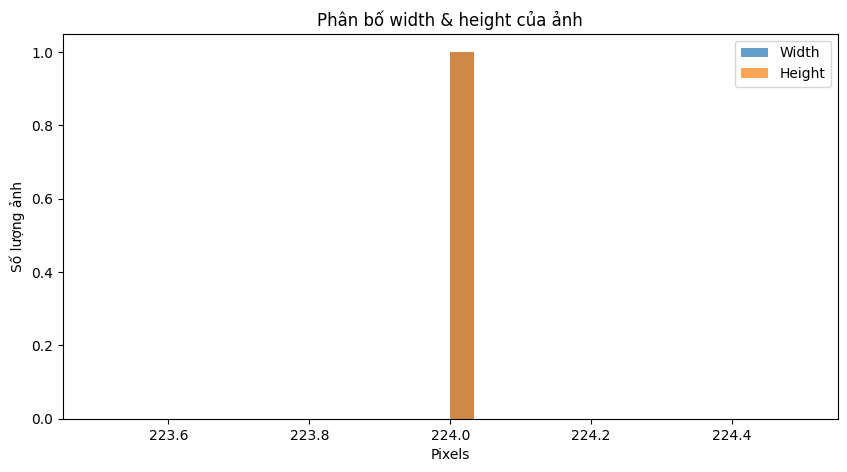

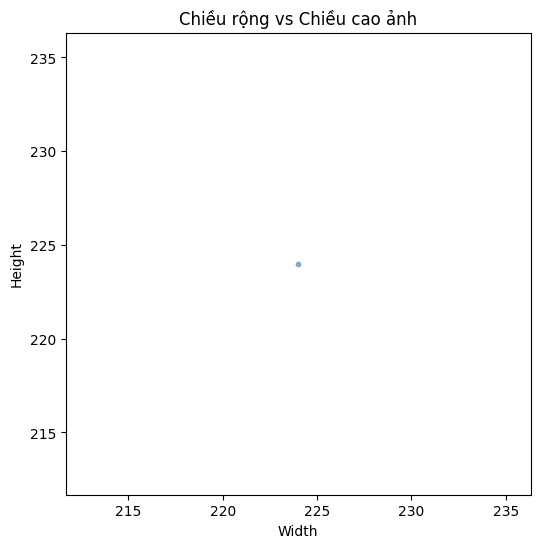

In [28]:

def collect_image_sizes(file_list):
  widths, heights = [], []
  for f in file_list:
    try:
      with Image.open(f) as img:
          w, h = img.size
          widths.append(w)
          heights.append(h)
    except Exception as e:
        print(f"Lỗi đọc {f}: {e}")
    return widths, heights

# Ví dụ
widths, heights = collect_image_sizes(images_path)

# Histogram phân bố width
plt.figure(figsize=(10,5))
plt.hist(widths, bins=30, alpha=0.7, label="Width")
plt.hist(heights, bins=30, alpha=0.7, label="Height")
plt.legend()
plt.title("Phân bố width & height của ảnh")
plt.xlabel("Pixels")
plt.ylabel("Số lượng ảnh")
plt.show()

# Scatter plot width vs height
plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.5, s=10)
plt.title("Chiều rộng vs Chiều cao ảnh")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()
